# Supplementary panel - Properties of ripples NATIM

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import pywt
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize
from matplotlib import colormaps
from matplotlib.colors import TwoSlopeNorm

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

## Parameters

In [4]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['human_data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates_human']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes_human' ### here the resulting dataframes will be saved
PATIENT_LIST = ['Patient2','Patient3']

FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']

DUAL_TH = [2.5,3.5]

## Data loading

In [5]:
# loading ripples detected with lowpass on 40 on envelope
df_r = load_ripples_df_all_humans(PATIENT_LIST,dual_th=[2.5,3.5],condition='All',params=params_analysis,
                       df_folder=DF_FOLDER,exclude_noisy=True,verbose=False)

Patient2
Patient3


In [6]:
df_r.keys()

Index(['channel_0_95', 'th_baseline', 'ICI time', 'freq', 'first_peak_sig_val',
       'first_pos_peak_time_ms', 'first_neg_peak_time_ms', 'time_0_sig',
       'start_time_ms', 'stop_time_ms', 'eyes_closed', 'duration_ms',
       'amplitude', 'LFP_at_pos_peak', 'LFP_at_neg_peak', 'peak_time_ms',
       'positive_peak_time_ms', 'negative_peak_time_ms',
       'envelope_peak_time_ms', 'num_of_zero_cross', 'time_first_zero_cross',
       'time_last_zero_cross', 'diff_after_before_peak', 'peak_position_ratio',
       'env_peak_position_ratio', 'mean ICI', 'std ICI', 'CV ICI',
       'bad_channel', 'start_rec_ms', 'stop_rec_ms', 'date', 'patient'],
      dtype='object')

## Functions

In [7]:
def calculate_ripple_rates_date_HUMAN(patient,dual_th=[2.5,3.5],params={},date='',
                              main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder='',verbose=False):
    """
    Calculates ripple rates for each channel, pooling all dates.

    Returns a dict with lists of rates for channels in all Rec.
    """
    condition = 'All'

    df_r = load_ripples_df_human(patient,dual_th=dual_th,dates=[date],condition=condition,
                           params=params_analysis,df_folder=df_folder,exclude_noisy=True,verbose=verbose)  # only including good channels
    all_arr_dict = {}
    ripple_rates_ch_list = []
    df_array = df_r

    if df_array.shape[0]>0:
        dur_rec_date_arr_ms = df_array.iloc[0]['stop_rec_ms'] - df_array.iloc[0]['start_rec_ms']  # might be slightly different for each array
        dur_rec_date_arr_s = dur_rec_date_arr_ms/1000
        for ch in range(95): #np.unique(df_array['channel_0_95']): 
            try:
                df_ch = df_array[df_array['channel_0_95']==ch]
                num_ripples_ch = df_ch.shape[0]
                ripple_rates_ch_list.append(num_ripples_ch/dur_rec_date_arr_s)
            except:
                ripple_rates_ch_list.append(0)
    else:
        if verbose:
            print(f'No data for {date}.')
        ripple_rates_ch_list = list(np.zeros(95))
        
    rates_dict = {'All': ripple_rates_ch_list,}
    all_arr_dict[0] = rates_dict  # just one arr.
    return all_arr_dict

In [8]:
def calculate_ripple_rates_fig1_HUMAN(patient,dual_th=[2.5,3.5],area=None,params={},
                              main_folder='/CSNG/studekat/ripple_band_project/',df_folder='',verbose=False):
    """
    Calculates ripple rates for each channel, pooling all dates.
    Area can be chosen: V1, V2, V12, V4, IT.

    Returns a dict with lists of rates for channels in all Rec.
    """
    condition = 'All'
    ripple_rates_ch_list = []

    all_dates = params['dates_human'][patient]
    for date in all_dates:
        df_r = load_ripples_df_human(patient,dual_th=dual_th,dates=[date],condition=condition,
                               params=params_analysis,df_folder=df_folder,exclude_noisy=True,verbose=verbose)  # only including good channels
        df_array = df_r
        if df_array.shape[0]>0:
            dur_rec_date_arr_ms = df_array.iloc[0]['stop_rec_ms'] - df_array.iloc[0]['start_rec_ms']  # might be slightly different for each array
            dur_rec_date_arr_s = dur_rec_date_arr_ms/1000
            for ch in np.unique(df_array['channel_0_95']): 
                df_ch = df_array[df_array['channel_0_95']==ch]
                num_ripples_ch = df_ch.shape[0]
                #df_ch = df_ch[df_ch['eyes_closed'].notna()]  # not using non-classified times of recording
                ripple_rates_ch_list.append(num_ripples_ch/dur_rec_date_arr_s)
        else:
            if verbose:
                print(f'No data for {patient}.')

    rates_dict = {'All': ripple_rates_ch_list,}
    return rates_dict

In [9]:
def calculate_ripple_prop_fig1_HUMAN(patient,dual_th = [2.5,3.5],prop='duration_ms',area=None,params={},
                              main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder='',verbose=False):
    """
    Calculates ripple prop. as chosen, pooling all dates.
    Area can be chosen.

    prop: duration_ms, amplitude, freq, CV ICI

    Returns a dict with lists of the values of a given prop. for channels in all Rec, EC, and EO.
    """
    condition = 'All'
    ripple_prop_list = []

    all_dates = params['dates_human'][patient]
    for date in all_dates:
        df_r = load_ripples_df_human(patient,dual_th=dual_th,dates=[date],condition=condition,
                               params=params_analysis,df_folder=df_folder,exclude_noisy=True)  # only including good channels
        df_array = df_r
        if df_array.shape[0]>0:
            ripple_prop_list.append(df_array[prop].values)
        else:
            if verbose:
                print(f'No data for {date}.')

    prop_dict = {'All': list_merge(ripple_prop_list),}
    return prop_dict

In [25]:
def plot_ripple_stats(data_dict,set_params={}):
    """
    Plotting statistics for ripples.
    """
    fig, ax = plt.subplots(dpi=200)
    fig.set_figwidth(set_params['plot_width'])
    fig.set_figheight(set_params['plot_height'])
    
    if 'title' in set_params.keys():
        ax.set_title(set_params['title'])

    palette = set_params['colors_patients']

    position = 0
    for patient in ['Patient2','Patient3']:
        df = pd.DataFrame([{"group": k, "value": v} for k, vals in data_dict.items() for v in vals])
        df = df[df['group']==patient]
        sns.boxplot(x='group',y='value',data=df,ax=ax, positions=[position],
                 palette=set_params['colors_patients'],hue='group',showfliers=False,
                boxprops=dict(facecolor="none", edgecolor=set_params['colors_patients'][patient], linewidth=1.5),
                                     medianprops=dict(color=set_params['colors_patients'][patient], linewidth=1.5),width=0.5,
                                    whiskerprops=dict(color=set_params['colors_patients'][patient], linewidth=1.5,visible=True),
                                    capprops=dict(color=set_params['colors_patients'][patient], linewidth=1.5,visible=True))
        position+=1
    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if 'y_label' in set_params.keys():
        ax.set_ylabel(set_params['y_label'])

    if 'x_label' in set_params.keys():
        ax.set_xlabel(set_params['x_label'])

    if 'ylim' in set_params.keys():
        ax.set_ylim(set_params['ylim'])  

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Subj1', 'Subj2'])

    plt.show()
    plt.close()
    return

## Plotting

In [26]:
set_params = {}
set_params['plot_width'] = 2
set_params['plot_height'] = 2
set_params['colors_patients'] = {'Patient2':'lightcoral','Patient3':'lightseagreen','Patient4':'plum'}

### Ripple rate per channel

In [27]:
rates_dict_animals = {}
for patient in PATIENT_LIST:
    rates_dict = calculate_ripple_rates_fig1_HUMAN(patient,dual_th = [2.5,3.5],params=params_analysis,
                                           main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder=DF_FOLDER,verbose=False)
    rates_dict_animals[patient] = rates_dict['All']

Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
P

In [28]:
set_params['title'] = '' #'Ripple rate' #f'{MONKEY_LIST}, Ripple rate'
set_params['ylim'] = [-0.05,1.5]
set_params['y_label'] = 'Rate [/s on channel]'
set_params['x_label'] = 'Patient'
#set_params['violin_bw'] = 0.2
#set_params['violin_alpha'] = 0.8

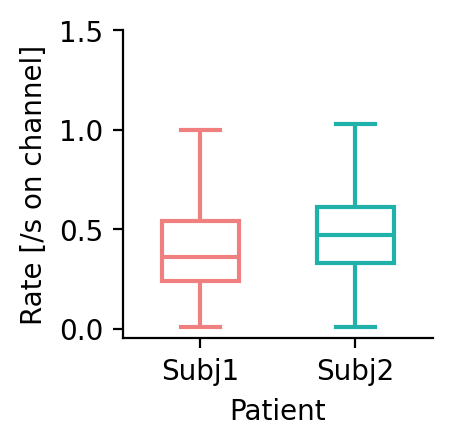

In [29]:
plot_ripple_stats(rates_dict_animals,set_params)

### Ripple duration

In [30]:
dur_dict_animals = {}
for patient in PATIENT_LIST:
    duration_dict = calculate_ripple_prop_fig1_HUMAN(patient,prop='duration_ms',dual_th = [2.5,3.5],params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder=DF_FOLDER,verbose=False)
    dur_dict_animals[patient] = duration_dict['All']

Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
P

In [31]:
set_params['title'] = '' 
set_params['ylim'] = [30,120]
set_params['y_label'] = 'Duration [ms]'
set_params['x_label'] = 'Patient'
set_params['cut_data'] = 500  # maximal data point allowed in the stats
#set_params['violin_bw'] = 0.8
#set_params['violin_alpha'] = 0.8

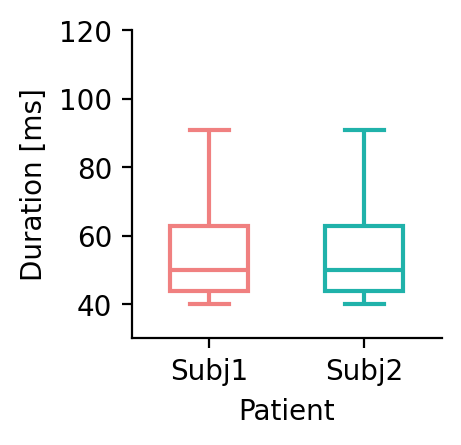

In [32]:
plot_ripple_stats(dur_dict_animals,set_params)

### Ripple amplitude

In [33]:
amp_dict_animals = {}
for patient in PATIENT_LIST:
    amp_dict = calculate_ripple_prop_fig1_HUMAN(patient,prop='amplitude',dual_th = [2.5,3.5],params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder=DF_FOLDER,verbose=False)
    amp_dict_animals[patient] = amp_dict['All']

Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
P

In [34]:
set_params['title'] = '' 
set_params['ylim'] = [2.5,12.5]
set_params['x_label'] = 'Patient'
set_params['y_label'] = 'Amplitude \n[z-scored u.]'
set_params['violin_bw'] = 1.5
set_params['violin_alpha'] = 0.8

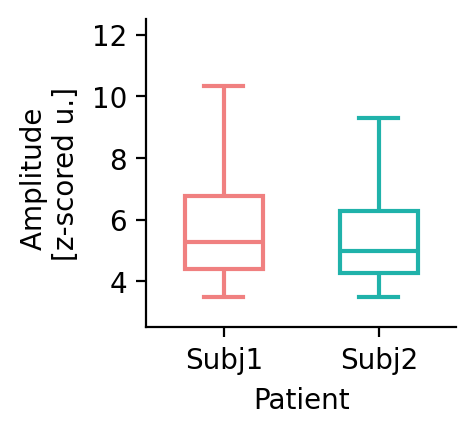

In [35]:
plot_ripple_stats(amp_dict_animals,set_params)

### Ripple frequency

In [36]:
freq_dict_animals = {}
for patient in PATIENT_LIST:
    freq_dict = calculate_ripple_prop_fig1_HUMAN(patient,prop='freq',dual_th = [2.5,3.5],params=params_analysis,
                                       main_folder='/CSNG/studekat/ripple_paper_clean/',df_folder=DF_FOLDER,verbose=False)
    freq_dict_animals[patient] = freq_dict['All']

Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient2
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
Patient3
P

In [37]:
set_params['title'] = '' #f'{MONKEY_LIST}, Frequency of ripples \n'
set_params['ylim'] = [70,150]
set_params['y_label'] = 'Frequency [Hz]'
set_params['x_label'] = 'Patient'
set_params['violin_bw'] = 0.2
set_params['violin_alpha'] = 0.8

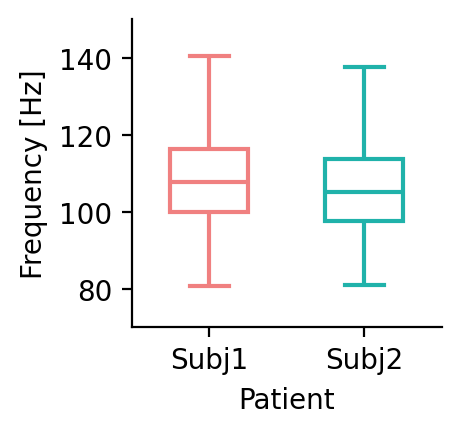

In [38]:
plot_ripple_stats(freq_dict_animals,set_params)